In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/hotel_bookings.csv")

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (119390, 32)

Columns:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']


In [4]:
df.isnull().sum().sort_values(ascending=False)

company                           112593
agent                              16340
country                              488
children                               4
arrival_date_month                     0
arrival_date_week_number               0
hotel                                  0
is_canceled                            0
stays_in_weekend_nights                0
arrival_date_day_of_month              0
adults                                 0
stays_in_week_nights                   0
babies                                 0
meal                                   0
lead_time                              0
arrival_date_year                      0
distribution_channel                   0
market_segment                         0
previous_bookings_not_canceled         0
is_repeated_guest                      0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
previous_cancellations                 0
deposit_type    

In [5]:
df["is_canceled"].value_counts()

is_canceled
0    75166
1    44224
Name: count, dtype: int64

In [6]:
df["is_canceled"].value_counts(normalize=True) * 100

is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64

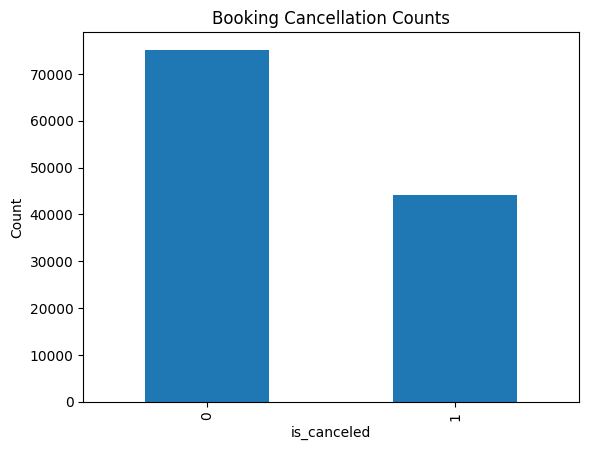

In [7]:
import matplotlib.pyplot as plt

df["is_canceled"].value_counts().plot(kind="bar")
plt.title("Booking Cancellation Counts")
plt.xlabel("is_canceled")
plt.ylabel("Count")
plt.show()

### Initial target variable insights

The target variable for this project is `is_canceled`.

Initial inspection shows that:
- 75,166 bookings were not cancelled.
- 44,224 bookings were cancelled.
- this means approximately 37.04% of bookings in the dataset were cancelled.

This would suggest the dataset is suitable for a cancellation prediction project, as there is a large number of cancellation cases available for analysis and modelling.

In [8]:
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [9]:
df.dtypes.value_counts()

int64      16
object     12
float64     4
Name: count, dtype: int64

### Data type summary

This dataset contains a mix of numeric and categorical features:
- 16 integer columns
- 12 object columns
- 4 float columns

Important for the modelling stage - because categorical variables need to be encoded before being used. Some float columns, like `agent`, `company`, and `children`, also contain missing values that will need to be handled during data cleaning.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [11]:
df["reservation_status"].value_counts()

reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64

In [12]:
pd.crosstab(df["reservation_status"], df["is_canceled"])

is_canceled,0,1
reservation_status,,
Canceled,0,43017
Check-Out,75166,0
No-Show,0,1207


### Leakage check: `reservation_status`

The `reservation_status` column closely linked to the target variable `is_canceled`:

- `Check-Out` aligns with non-cancelled bookings
- `Canceled` aligns with cancelled bookings
- `No-Show` also aligns with cancelled bookings

`reservation_status` would give the model information about the final outcome of the booking, rather than information that would have been known in advance. This makes it a data leakage risk, as such it should be left out of the features used for modelling later in the project.

In [13]:
df["reservation_status_date"].head()

0    2015-07-01
1    2015-07-01
2    2015-07-02
3    2015-07-02
4    2015-07-03
Name: reservation_status_date, dtype: object

In [14]:
df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"])
df["reservation_status_date"].dtype

dtype('<M8[ns]')

### Note on `reservation_status_date`

The `reservation_status_date` column converts properly to datetime format, which shows the values are valid dates.

However, this column could still cause data leakage issues if used for modelling, because it is linked to the final booking outcome. This means it includes information that would not normally be known at the time a prediction is made.

As such, this column should be handled carefully and will likely be removed from the modelling features later on.

In [15]:
df["hotel"].value_counts()

hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

In [16]:
df["hotel"].value_counts(normalize=True) * 100

hotel
City Hotel      66.446101
Resort Hotel    33.553899
Name: proportion, dtype: float64

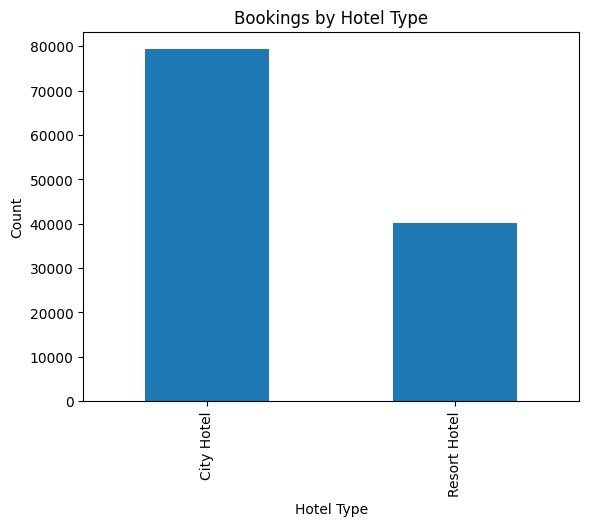

In [17]:
df["hotel"].value_counts().plot(kind="bar")
plt.title("Bookings by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Count")
plt.show()

In [18]:
pd.crosstab(df["hotel"], df["is_canceled"], normalize="index") * 100

is_canceled,0,1
hotel,,
City Hotel,58.273037,41.726963
Resort Hotel,72.236645,27.763355


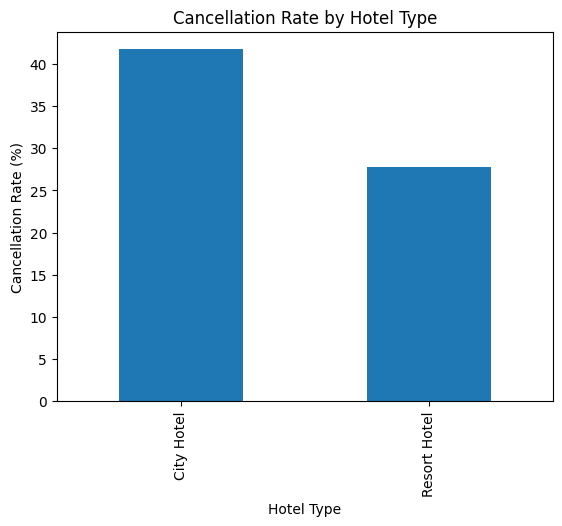

In [19]:
hotel_cancel_rate = pd.crosstab(df["hotel"], df["is_canceled"], normalize="index") * 100
hotel_cancel_rate[1].plot(kind="bar")
plt.title("Cancellation Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate (%)")
plt.show()

In [20]:
df["lead_time"].describe()

count    119390.000000
mean        104.011416
std         106.863097
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64

In [21]:
df.groupby("is_canceled")["lead_time"].mean()

is_canceled
0     79.984687
1    144.848815
Name: lead_time, dtype: float64

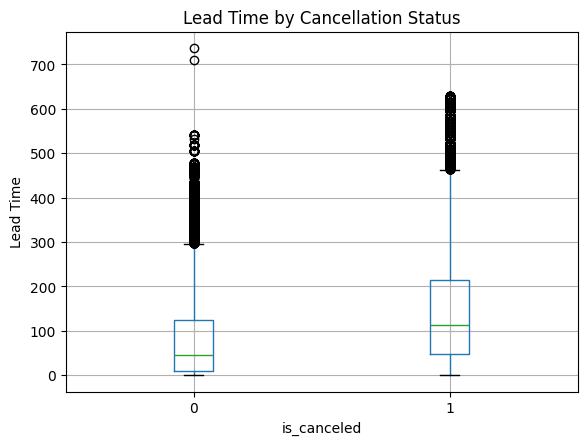

In [22]:
df.boxplot(column="lead_time", by="is_canceled")
plt.title("Lead Time by Cancellation Status")
plt.suptitle("")
plt.xlabel("is_canceled")
plt.ylabel("Lead Time")
plt.show()

### Lead time insight

The `lead_time` feature appears to be strongly related to cancellation behaviour.

Initial analysis shows that:
- non-cancelled bookings had an average lead time of about 79.98 days.
- cancelled bookings had an average lead time of about 144.85 days.

The boxplot also shows that cancelled bookings generally have a higher lead time distribution than non-cancelled bookings. This suggests that bookings made further in advance may be more likely to cancel, making `lead_time` a potentially important feature for modelling.

In [23]:
df["adr"].describe()

count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

In [24]:
df.groupby("is_canceled")["adr"].mean()

is_canceled
0     99.987693
1    104.964333
Name: adr, dtype: float64

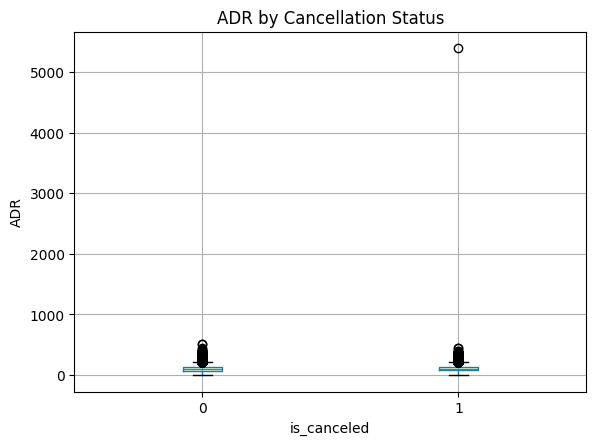

In [25]:
df.boxplot(column="adr", by="is_canceled")
plt.title("ADR by Cancellation Status")
plt.suptitle("")
plt.xlabel("is_canceled")
plt.ylabel("ADR")
plt.show()

### ADR insight

The `adr` feature shows some difference between cancelled and non-cancelled bookings, but the separation is less clear than for `lead_time`.

Initial analysis shows that:
- non-cancelled bookings had an average ADR of about 99.99.
- cancelled bookings had an average ADR of about 104.96.

The boxplot also highlights extreme outliers, including unusually high ADR values and at least one negative value. This suggests that ADR may still be useful for modelling, but it will require additional cleaning or outlier handling later on.

In [26]:
df["total_of_special_requests"].describe()

count    119390.000000
mean          0.571363
std           0.792798
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           5.000000
Name: total_of_special_requests, dtype: float64

In [27]:
df.groupby("is_canceled")["total_of_special_requests"].mean()

is_canceled
0    0.714060
1    0.328826
Name: total_of_special_requests, dtype: float64

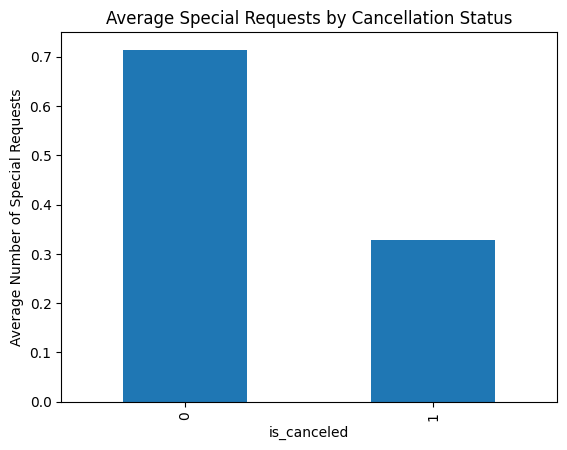

In [28]:
special_requests_by_cancel = df.groupby("is_canceled")["total_of_special_requests"].mean()
special_requests_by_cancel.plot(kind="bar")
plt.title("Average Special Requests by Cancellation Status")
plt.xlabel("is_canceled")
plt.ylabel("Average Number of Special Requests")
plt.show()

### Special requests insight

The `total_of_special_requests` feature appears to be related to cancellation behaviour.

Initial analysis shows that:
- non-cancelled bookings had an average of about 0.71 special requests.
- cancelled bookings had an average of about 0.33 special requests.

This suggests that bookings with more special requests may be less likely to cancel. One possible explanation is that guests making special requests may be more committed to the booking, making this a potentially useful feature for modelling.

In [29]:
df["deposit_type"].value_counts()

deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64

In [30]:
pd.crosstab(df["deposit_type"], df["is_canceled"], normalize="index") * 100

is_canceled,0,1
deposit_type,,
No Deposit,71.622978,28.377022
Non Refund,0.637554,99.362446
Refundable,77.777778,22.222222


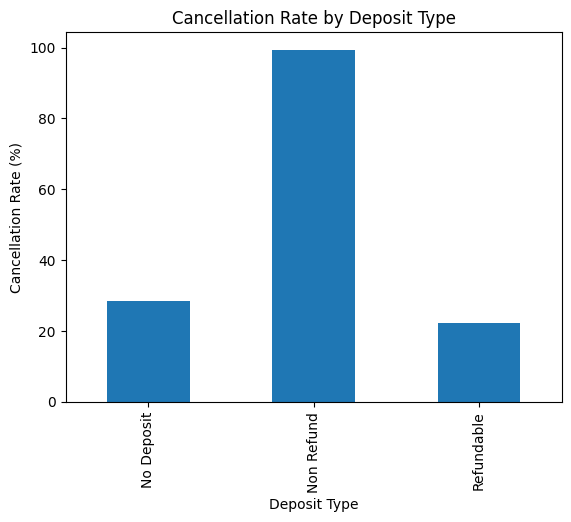

In [31]:
deposit_cancel_rate = pd.crosstab(df["deposit_type"], df["is_canceled"], normalize="index") * 100
deposit_cancel_rate[1].plot(kind="bar")
plt.title("Cancellation Rate by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Cancellation Rate (%)")
plt.show()

### Deposit type insight

The `deposit_type` feature appears to be strongly related to cancellation behaviour.

Initial analysis shows that:
- `No Deposit` bookings had a cancellation rate of about 28.38%
- `Non Refund` bookings had a cancellation rate of about 99.36%
- `Refundable` bookings had a cancellation rate of about 22.22%

Initially this seems surprising, but a cancelled booking does not necessarily mean the guest received a refund. It may simply mean the reservation did not go ahead, while the hotel still retained payment under the booking terms. (This will be looked at further)

This suggests that `deposit_type` may be one of the strongest predictive features in the dataset, though it should be investigated carefully because it may also just reflect hotel policy and booking conditions.

In [32]:
df["market_segment"].value_counts()

market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

In [33]:
pd.crosstab(df["market_segment"], df["is_canceled"], normalize="index") * 100

is_canceled,0,1
market_segment,,
Aviation,78.059072,21.940928
Complementary,86.944818,13.055182
Corporate,81.265345,18.734655
Direct,84.658099,15.341901
Groups,38.937964,61.062036
Offline TA/TO,65.683967,34.316033
Online TA,63.278857,36.721143
Undefined,0.000000,100.000000


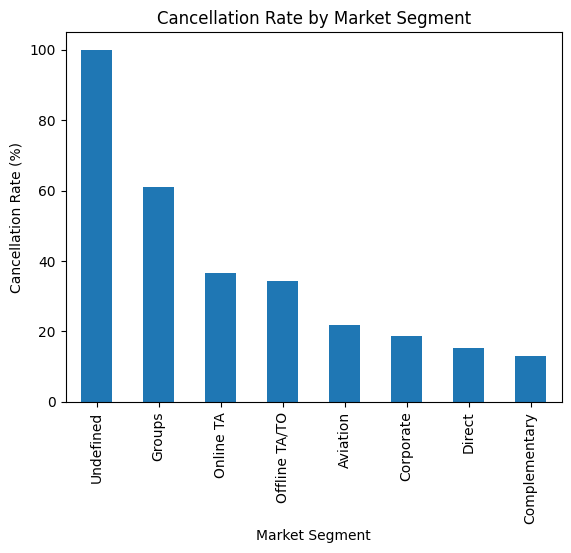

In [34]:
market_cancel_rate = pd.crosstab(df["market_segment"], df["is_canceled"], normalize="index") * 100
market_cancel_rate[1].sort_values(ascending=False).plot(kind="bar")
plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Cancellation Rate (%)")
plt.show()

### Market segment insight

The `market_segment` feature appears to be related to cancellation behaviour.

Initial analysis shows that:
- `Groups` bookings had a very high cancellation rate of about 61.06%.
- `Online TA` bookings also had a relatively high cancellation rate of about 36.72%.
- `Direct`, `Corporate`, and `Complementary` bookings had notably lower cancellation rates.

This would suggest that the way a booking is sourced may be an important predictor of whether it will be cancelled. The result also indicates that customer type and booking channel behaviour may differ quite a bit across market segments.

In [35]:
df["distribution_channel"].value_counts()

distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: count, dtype: int64

In [36]:
pd.crosstab(df["distribution_channel"], df["is_canceled"], normalize="index") * 100

is_canceled,0,1
distribution_channel,,
Corporate,77.924217,22.075783
Direct,82.540116,17.459884
GDS,80.829016,19.170984
TA/TO,58.974149,41.025851
Undefined,20.000000,80.000000


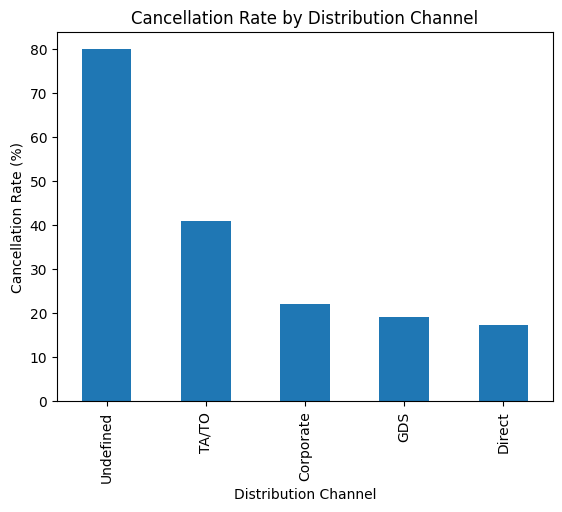

In [37]:
channel_cancel_rate = pd.crosstab(df["distribution_channel"], df["is_canceled"], normalize="index") * 100
channel_cancel_rate[1].sort_values(ascending=False).plot(kind="bar")
plt.title("Cancellation Rate by Distribution Channel")
plt.xlabel("Distribution Channel")
plt.ylabel("Cancellation Rate (%)")
plt.show()

### Distribution channel insight

The `distribution_channel` feature also appears to be related to cancellation behaviour.

Initial analysis shows that:
- `TA/TO` bookings had the highest cancellation rate at about 41.03%
- `Direct` bookings had a much lower cancellation rate of about 17.46%
- `Corporate` and `GDS` bookings also had relatively lower cancellation rates

This suggests that the route through which the booking was made may influence the likelihood of cancellation. It also supports the market segment findings, where third party and intermediary booking channels appeared to be more cancellation prone than direct bookings.

In [38]:
df["customer_type"].value_counts()

customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64

In [39]:
pd.crosstab(df["customer_type"], df["is_canceled"], normalize="index") * 100

is_canceled,0,1
customer_type,,
Contract,69.038273,30.961727
Group,89.774697,10.225303
Transient,59.253680,40.746320
Transient-Party,74.570132,25.429868


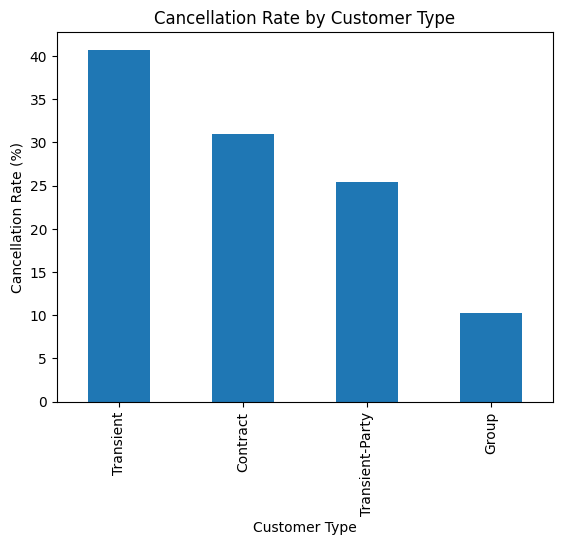

In [40]:
customer_cancel_rate = pd.crosstab(df["customer_type"], df["is_canceled"], normalize="index") * 100
customer_cancel_rate[1].sort_values(ascending=False).plot(kind="bar")
plt.title("Cancellation Rate by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Cancellation Rate (%)")
plt.show()

### Customer type insight

The `customer_type` feature appears to be related to cancellation behaviour.

Initial analysis shows that:
- `Transient` bookings had the highest cancellation rate at about 40.75%.
- `Transient-Party` bookings had a lower cancellation rate of about 25.43%.
- `Contract` bookings were about 30.96%.
- `Group` bookings had the lowest cancellation rate, even though this category is much smaller.

This suggests that customer booking behaviour differs across customer types, and that `customer_type` may be a useful feature for predicting cancellations.